In [1]:
## imports
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.metrics import classification_report, accuracy_score

In [2]:
## Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
## preprocessing

## flattening
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

## normalization
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
def build_model(activation_function):

    model = Sequential()

    model.add(Dense(128, activation=activation_function, input_shape=(784,)))
    model.add(Dense(64, activation=activation_function))
    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer='sgd',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

### EXPERIMENT 1 — ReLU + SGD

In [38]:
## training

In [5]:

start = time.time()

model_relu = build_model('relu')

history_relu = model_relu.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

time_relu = time.time() - start

C:\Anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8057 - loss: 0.7232 - val_accuracy: 0.9042 - val_loss: 0.3411
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9087 - loss: 0.3239 - val_accuracy: 0.9227 - val_loss: 0.2691
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9241 - loss: 0.2666 - val_accuracy: 0.9327 - val_loss: 0.2352
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9348 - loss: 0.2302 - val_accuracy: 0.9390 - val_loss: 0.2119
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9415 - loss: 0.2041 - val_accuracy: 0.9482 - val_loss: 0.1873


In [39]:
## evaluation

In [6]:
y_pred_relu = np.argmax(model_relu.predict(x_test), axis=1)

print("ReLU Accuracy:", accuracy_score(y_test, y_pred_relu))
print(classification_report(y_test, y_pred_relu))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
ReLU Accuracy: 0.9452
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.98      0.98      0.98      1135
           2       0.95      0.94      0.94      1032
           3       0.93      0.94      0.93      1010
           4       0.94      0.95      0.94       982
           5       0.95      0.92      0.93       892
           6       0.95      0.95      0.95       958
           7       0.93      0.95      0.94      1028
           8       0.94      0.92      0.93       974
           9       0.95      0.92      0.93      1009

    accuracy                           0.95     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.95      0.95      0.95     10000



### EXPERIMENT 2 — Sigmoid + SGD

In [40]:
## traning

In [7]:
start = time.time()

model_sigmoid = build_model('sigmoid')

history_sigmoid = model_sigmoid.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

time_sigmoid = time.time() - start

C:\Anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3081 - loss: 2.2374 - val_accuracy: 0.4503 - val_loss: 2.1255
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.5948 - loss: 1.9245 - val_accuracy: 0.6284 - val_loss: 1.6521
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6969 - loss: 1.3789 - val_accuracy: 0.7546 - val_loss: 1.1163
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7699 - loss: 0.9794 - val_accuracy: 0.8075 - val_loss: 0.8276
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8140 - loss: 0.7673 - val_accuracy: 0.8467 - val_loss: 0.6666


In [41]:
## evaluation

In [8]:
y_pred_sigmoid = np.argmax(model_sigmoid.predict(x_test), axis=1)

print("Sigmoid Accuracy:", accuracy_score(y_test, y_pred_sigmoid))
print(classification_report(y_test, y_pred_sigmoid))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step   
Sigmoid Accuracy: 0.8404
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       980
           1       0.88      0.97      0.92      1135
           2       0.88      0.82      0.85      1032
           3       0.81      0.84      0.82      1010
           4       0.78      0.82      0.80       982
           5       0.82      0.67      0.74       892
           6       0.88      0.92      0.90       958
           7       0.88      0.88      0.88      1028
           8       0.82      0.72      0.77       974
           9       0.76      0.76      0.76      1009

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



### EXPERIMENT 3 — Tanh + SGD

In [42]:
## training

In [9]:
start = time.time()

model_tanh = build_model('tanh')

history_tanh = model_tanh.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

time_tanh = time.time() - start

C:\Anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8388 - loss: 0.6379 - val_accuracy: 0.9033 - val_loss: 0.3619
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9035 - loss: 0.3462 - val_accuracy: 0.9151 - val_loss: 0.2963
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9153 - loss: 0.2958 - val_accuracy: 0.9228 - val_loss: 0.2671
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9243 - loss: 0.2649 - val_accuracy: 0.9301 - val_loss: 0.2445
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9301 - loss: 0.2417 - val_accuracy: 0.9359 - val_loss: 0.2258


In [43]:
## evaluation

In [10]:
y_pred_tanh = np.argmax(model_tanh.predict(x_test), axis=1)

print("Tanh Accuracy:", accuracy_score(y_test, y_pred_tanh))
print(classification_report(y_test, y_pred_tanh))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Tanh Accuracy: 0.9366
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.97      0.98      0.98      1135
           2       0.94      0.92      0.93      1032
           3       0.93      0.91      0.92      1010
           4       0.93      0.95      0.94       982
           5       0.92      0.90      0.91       892
           6       0.94      0.95      0.95       958
           7       0.94      0.94      0.94      1028
           8       0.91      0.91      0.91       974
           9       0.93      0.91      0.92      1009

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



### ACTIVATION COMPARISON GRAPH

### Accuracy Graph

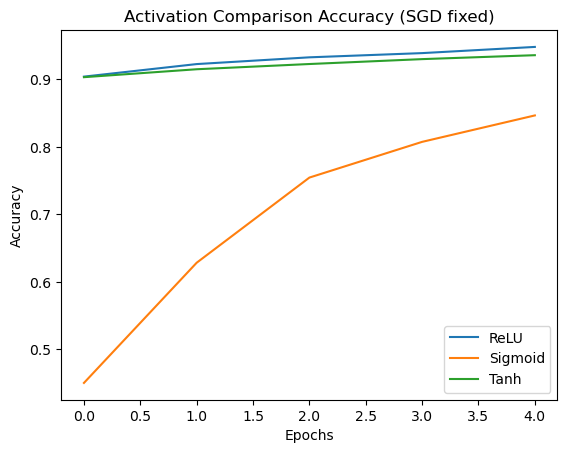

In [34]:
plt.plot(history_relu.history['val_accuracy'], label='ReLU')
plt.plot(history_sigmoid.history['val_accuracy'], label='Sigmoid')
plt.plot(history_tanh.history['val_accuracy'], label='Tanh')

plt.title("Activation Comparison Accuracy (SGD fixed)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### LOSS GRAPH

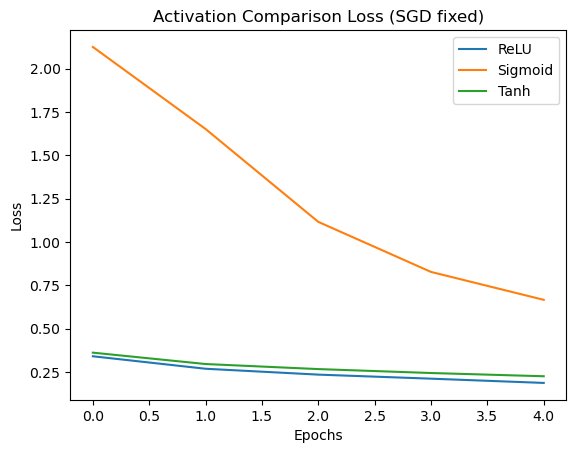

In [35]:
plt.plot(history_relu.history['val_loss'], label='ReLU')
plt.plot(history_sigmoid.history['val_loss'], label='Sigmoid')
plt.plot(history_tanh.history['val_loss'], label='Tanh')

plt.title("Activation Comparison Loss (SGD fixed)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## training vs validation

### Loss

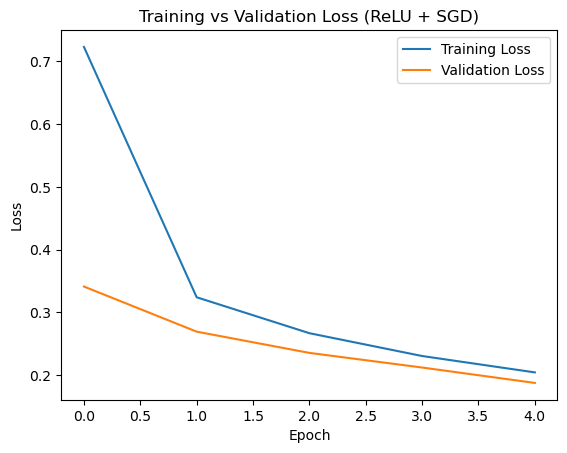

In [14]:
plt.plot(history_relu.history['loss'], label='Training Loss')
plt.plot(history_relu.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss (ReLU + SGD)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### accuracy

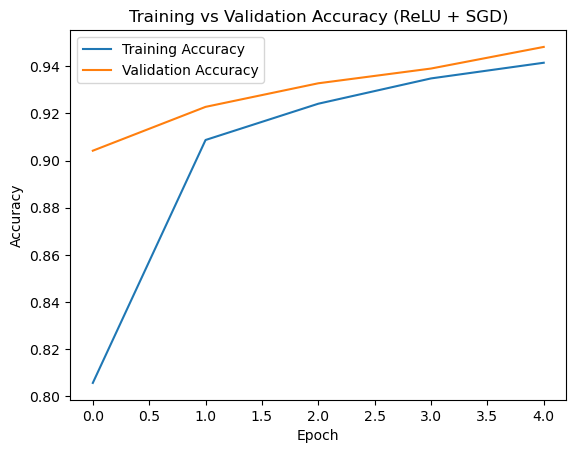

In [15]:
plt.plot(history_relu.history['accuracy'], label='Training Accuracy')
plt.plot(history_relu.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy (ReLU + SGD)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## OPTIMIZER EXPERIMENT (FIX ACTIVATION)

In [17]:
def build_optimizer_model(optimizer):
    
    model = Sequential()

    model.add(Dense(128, activation='relu', input_shape=(784,)))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

### Relu + SGD

In [44]:
## training

In [18]:
model_relu_sgd = build_optimizer_model('sgd')

history_relu_sgd = model_relu_sgd.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

C:\Anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8176 - loss: 0.6935 - val_accuracy: 0.9033 - val_loss: 0.3418
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9075 - loss: 0.3237 - val_accuracy: 0.9216 - val_loss: 0.2766
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9224 - loss: 0.2715 - val_accuracy: 0.9298 - val_loss: 0.2428
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9319 - loss: 0.2378 - val_accuracy: 0.9385 - val_loss: 0.2189
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9391 - loss: 0.2115 - val_accuracy: 0.9447 - val_loss: 0.1979


In [45]:
## evaluation

In [19]:
y_pred_relu_sgd = np.argmax(model_relu_sgd.predict(x_test), axis=1)

print("relu + SGD Accuracy:",
      accuracy_score(y_test, y_pred_relu_sgd))

print(classification_report(y_test, y_pred_relu_sgd))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
relu + SGD Accuracy: 0.9414
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       0.97      0.98      0.98      1135
           2       0.95      0.93      0.94      1032
           3       0.94      0.92      0.93      1010
           4       0.93      0.95      0.94       982
           5       0.90      0.93      0.92       892
           6       0.95      0.95      0.95       958
           7       0.95      0.92      0.94      1028
           8       0.95      0.90      0.93       974
           9       0.91      0.93      0.92      1009

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



### relu + RMSprop

In [46]:
## training

In [20]:
model_relu_rms = build_optimizer_model('rmsprop')

history_relu_rms = model_relu_rms.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

C:\Anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9205 - loss: 0.2712 - val_accuracy: 0.9574 - val_loss: 0.1472
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9647 - loss: 0.1192 - val_accuracy: 0.9689 - val_loss: 0.1138
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9743 - loss: 0.0856 - val_accuracy: 0.9741 - val_loss: 0.1012
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9794 - loss: 0.0668 - val_accuracy: 0.9734 - val_loss: 0.0979
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9840 - loss: 0.0543 - val_accuracy: 0.9688 - val_loss: 0.1262


In [47]:
## evaluation

In [21]:
y_pred_relu_rms = np.argmax(model_relu_rms.predict(x_test), axis=1)

print("relu + RMSprop Accuracy:",
      accuracy_score(y_test, y_pred_relu_rms))

print(classification_report(y_test, y_pred_relu_rms))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
relu + RMSprop Accuracy: 0.9722
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.98      0.97      1032
           3       0.96      0.99      0.97      1010
           4       0.99      0.94      0.97       982
           5       0.98      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.99      0.96      0.97      1028
           8       0.94      0.98      0.96       974
           9       0.96      0.97      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



### Optimizer Comparison Graph

### Accuracy 

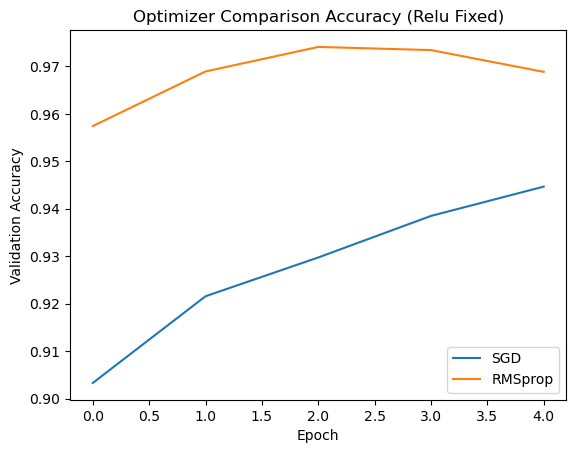

In [36]:
plt.plot(history_relu_sgd.history['val_accuracy'],
         label='SGD')

plt.plot(history_relu_rms.history['val_accuracy'],
         label='RMSprop')

plt.title("Optimizer Comparison Accuracy (Relu Fixed)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

### Loss

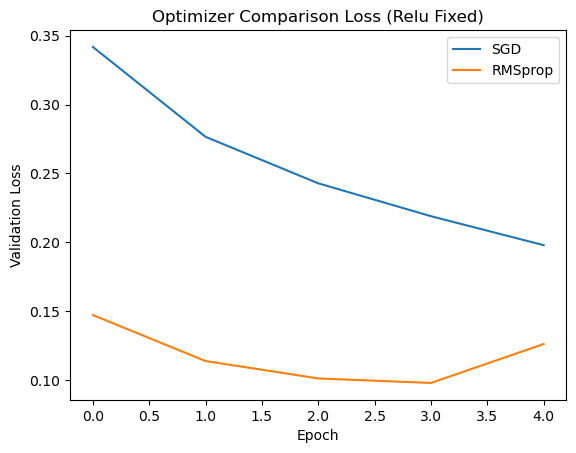

In [37]:
plt.plot(history_relu_sgd.history['val_loss'],
         label='SGD')

plt.plot(history_relu_rms.history['val_loss'],
         label='RMSprop')

plt.title("Optimizer Comparison Loss (Relu Fixed)")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

## COST FUNCTION EXPERIMENT

In [25]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [49]:
## model 1 categorical CE
model_cat = Sequential()

model_cat.add(Dense(128, activation='relu', input_shape=(784,)))
model_cat.add(Dense(64, activation='relu'))
model_cat.add(Dense(10, activation='softmax'))

model_cat.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### TRAIN MODEL

In [30]:
history_cat = model_cat.fit(
    x_train,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9207 - loss: 0.2712 - val_accuracy: 0.9577 - val_loss: 0.1396
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9640 - loss: 0.1208 - val_accuracy: 0.9673 - val_loss: 0.1109
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9747 - loss: 0.0851 - val_accuracy: 0.9706 - val_loss: 0.1098
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9801 - loss: 0.0678 - val_accuracy: 0.9752 - val_loss: 0.0914
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9832 - loss: 0.0554 - val_accuracy: 0.9741 - val_loss: 0.1092


### EVALUATION

In [31]:
y_pred_cat = np.argmax(model_cat.predict(x_test), axis=1)

print("Categorical Crossentropy Accuracy:", accuracy_score(y_test, y_pred_cat))
print(classification_report(y_test, y_pred_cat))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step   
Categorical Crossentropy Accuracy: 0.9758
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.94      0.96       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.93      0.98      0.96       974
           9       0.99      0.95      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [55]:
## model 2 Sparse CE
model_sparse = Sequential()

model_sparse.add(Dense(128, activation='relu', input_shape=(784,)))
model_sparse.add(Dense(64, activation='relu'))
model_sparse.add(Dense(10, activation='softmax'))

model_sparse.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

C:\Anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [56]:
## train
history_sparse = model_sparse.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8268 - loss: 0.6714 - val_accuracy: 0.9056 - val_loss: 0.3376
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9087 - loss: 0.3179 - val_accuracy: 0.9233 - val_loss: 0.2712
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9248 - loss: 0.2633 - val_accuracy: 0.9291 - val_loss: 0.2433
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9349 - loss: 0.2289 - val_accuracy: 0.9411 - val_loss: 0.2091
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9425 - loss: 0.2024 - val_accuracy: 0.9488 - val_loss: 0.1878


In [57]:
## evaluation
y_pred_sparse = np.argmax(model_sparse.predict(x_test), axis=1)

print("Sparse CE Accuracy:", accuracy_score(y_test, y_pred_sparse))
print(classification_report(y_test, y_pred_sparse))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Sparse CE Accuracy: 0.9457
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       0.98      0.98      0.98      1135
           2       0.94      0.94      0.94      1032
           3       0.92      0.95      0.93      1010
           4       0.95      0.94      0.94       982
           5       0.96      0.90      0.93       892
           6       0.95      0.96      0.95       958
           7       0.95      0.94      0.94      1028
           8       0.92      0.94      0.93       974
           9       0.94      0.91      0.93      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.94      0.95     10000
weighted avg       0.95      0.95      0.95     10000



## LOSS GRAPH

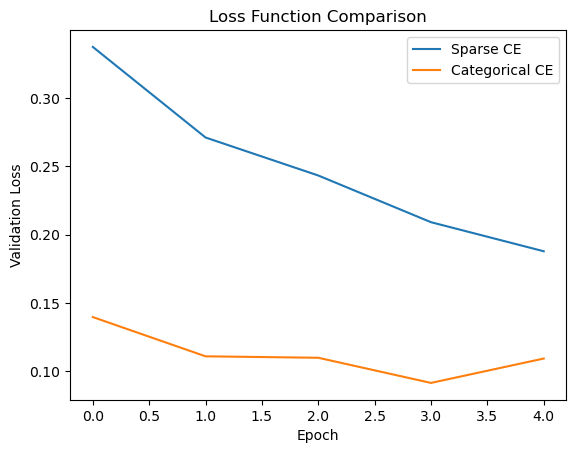

In [58]:
plt.plot(history_sparse.history['val_loss'], label='Sparse CE')
plt.plot(history_cat.history['val_loss'], label='Categorical CE')

plt.title("Loss Function Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

## ACCURACY GRAPH

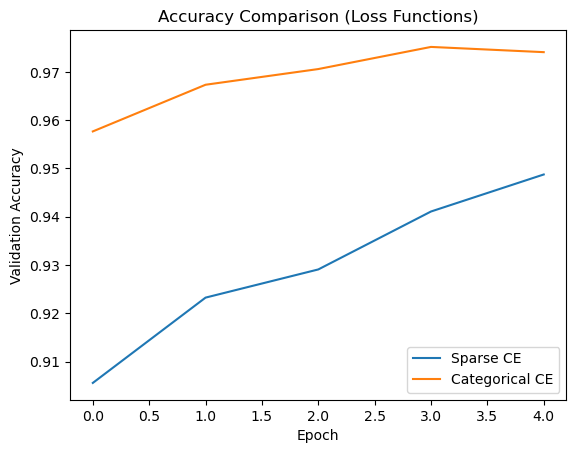

In [59]:
plt.plot(history_sparse.history['val_accuracy'], label='Sparse CE')
plt.plot(history_cat.history['val_accuracy'], label='Categorical CE')

plt.title("Accuracy Comparison (Loss Functions)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()